```markdown
# Caso de estudio alternativo: Apertura comercial e Inversión Extranjera Directa en América Latina

Este notebook tiene como objetivo introducir al/la estudiante al análisis de correlación y regresión lineal simple para evaluar relaciones entre variables macroeconómicas clave en América Latina. No requiere conocimientos previos de estructuras de datos complejas.

## Pregunta de investigación:
¿Existe una relación entre el grado de apertura comercial (medido como la suma de exportaciones e importaciones sobre el PIB) y el flujo de Inversión Extranjera Directa (IED) recibido por los países de América Latina?

## Datos:
Utilizaremos indicadores del Banco Mundial para un panel de países latinoamericanos durante un periodo de 15 a 20 años:
*   **Apertura comercial:** (Exportaciones + Importaciones) / PIB
*   **IED neta:** Entradas netas de IED (% del PIB)
*   **PIB per cápita:** (como variable de control)

## Pasos:
1.  Instalación de librerías necesarias.
2.  Extracción de los indicadores para los países seleccionados, usando `wbgapi`.
3.  Limpieza y reestructuración de los datos con `pandas`.
4.  Cálculo de la correlación simple y visualización.
5.  Ajuste de un modelo de regresión lineal simple con `statsmodels.OLS`.
6.  Discusión de los resultados.
```

```markdown
## 1. Instalación de librerías

Instalaremos `wbgapi` para la extracción de datos de la API del Banco Mundial.
```

In [ ]:
!pip install wbgapi pandas scipy statsmodels matplotlib --quiet

```markdown
## 2. Extracción de datos del Banco Mundial con `wbgapi`

Vamos a extraer los indicadores de Apertura Comercial, IED neta (% del PIB) y PIB per cápita para un panel de países de América Latina durante un período de 20 años (2000-2019).

### Indicadores a utilizar:
*   **Apertura Comercial (Trade openness):** `NE.EXP.GNFS.ZS` (Exportaciones de bienes y servicios (% del PIB)) + `NE.IMP.GNFS.ZS` (Importaciones de bienes y servicios (% del PIB)). La suma de estos dos es una proxy común para la apertura comercial.
*   **IED neta (% del PIB):** `BX.KLT.DINV.CD.WD` (Inversión Extranjera Directa, entradas netas de la balanza de pagos (BDP), (% del PIB))
*   **PIB per cápita (constante en dólares de 2015):** `NY.GDP.PCAP.KD` (PIB per cápita (US$ a precios constantes de 2015))

### Países de América Latina (ejemplo):
Vamos a seleccionar un conjunto representativo de países de América Latina.
```

In [ ]:
import wbgapi as wb
import pandas as pd
import google.colab.data_table

# Definir los códigos de los indicadores del Banco Mundial
# NE.EXP.GNFS.ZS: Exportaciones de bienes y servicios (% del PIB)
# NE.IMP.GNFS.ZS: Importaciones de bienes y servicios (% del PIB)
# BM.KLT.DINV.WD.GD.ZS: Inversión extranjera directa, entradas netas (% del PIB) - INDICADOR CORREGIDO
# NY.GDP.PCAP.KD: PIB per cápita (US$ a precios constantes de 2015) - Variable de control

indicators = {
    'NE.EXP.GNFS.ZS': 'Exports_GDP',
    'NE.IMP.GNFS.ZS': 'Imports_GDP',
    'BX.KLT.DINV.WD.GD.ZS': 'FDI_Net_Inflows_GDP', # IED neta como % del PIB
    'NY.GDP.PCAP.KD': 'GDP_Per_Capita_Constant_2015_USD'
}

# Definir los países de América Latina (códigos ISO de 3 letras)
# Puedes ajustar esta lista según tus necesidades
countries_latam = [
    'ARG', 'BOL', 'BRA', 'CHL', 'COL', 'CRI', 'ECU', 'SLV', 'GTM',
    'MEX', 'PRY', 'PER', 'URY', 'DOM' # Se eliminó 'VEN', 'NIC', 'PAN', 'HND'
]

# Definir el rango de años
years = range(2000, 2020) # Por ejemplo, 20 años desde 2000 hasta 2019

print(f"Extrayendo datos para {len(countries_latam)} países y {len(years)} años...")

# Función para extraer datos por indicador
def fetch_data(indicator_code, countries, years):
    try:
        df = wb.data.DataFrame(
            series=indicator_code,
            economy=countries,
            time=range(years.start, years.stop), # wbgapi prefiere el rango directamente
            skipAggs=True, # Saltar agregados regionales o de grupos de ingresos
            labels=False # Se eliminó labels=True y columns='series' para evitar errores de decodificación JSON
        )
        return df
    except Exception as e:
        print(f"Error al obtener datos para el indicador {indicator_code}: {e}")
        return pd.DataFrame()

all_data = []

for wb_code, friendly_name in indicators.items():
    print(f"Obteniendo: {friendly_name} ({wb_code})...")
    df_indicator = fetch_data(wb_code, countries_latam, years)
    if not df_indicator.empty:
        df_indicator = df_indicator.stack().reset_index()
        # El DataFrame resultante de stack().reset_index() ahora tiene 3 columnas:
        # 'economy', 'level_1' (el tiempo/año), y '0' (el valor).
        # Asignamos los nombres correctos para estas 3 columnas y luego añadimos
        # las columnas 'indicator_wb_code' e 'indicator' manualmente.
        df_indicator.columns = ['country_code', 'year_str', 'value']
        df_indicator['indicator_wb_code'] = wb_code # Añadir el código del indicador del Banco Mundial
        df_indicator['indicator'] = friendly_name
        df_indicator['year'] = df_indicator['year_str'].str.extract(r'YR(\d{4})').astype(int)
        all_data.append(df_indicator)
    else:
        print(f"No se encontraron datos para {friendly_name} ({wb_code})")

if all_data:
    df_raw = pd.concat(all_data, ignore_index=True)
    print("\nPrimeras 5 filas de los datos brutos extraídos:")
    display(df_raw.head())
    print(f"Total de registros: {len(df_raw)}")

    # Display df_raw using Colab's data_table
    google.colab.data_table.enable_dataframe_formatter()
    print("\nTabla interactiva de los datos brutos extraídos:")
    display(google.colab.data_table.DataTable(df_raw, include_index=False))
else:
    print("No se pudieron extraer datos para ningún indicador.")

Extrayendo datos para 14 países y 20 años...
Obteniendo: Exports_GDP (NE.EXP.GNFS.ZS)...
Obteniendo: Imports_GDP (NE.IMP.GNFS.ZS)...
Obteniendo: FDI_Net_Inflows_GDP (BX.KLT.DINV.WD.GD.ZS)...
Obteniendo: GDP_Per_Capita_Constant_2015_USD (NY.GDP.PCAP.KD)...

Primeras 5 filas de los datos brutos extraídos:


,country_code,year_str,value,indicator_wb_code,indicator,year
0,ARG,YR2000,10.986375,NE.EXP.GNFS.ZS,Exports_GDP,2000
1,ARG,YR2001,11.579008,NE.EXP.GNFS.ZS,Exports_GDP,2001
2,ARG,YR2002,28.382597,NE.EXP.GNFS.ZS,Exports_GDP,2002
3,ARG,YR2003,25.930943,NE.EXP.GNFS.ZS,Exports_GDP,2003
4,ARG,YR2004,23.847619,NE.EXP.GNFS.ZS,Exports_GDP,2004


Total de registros: 1120

Tabla interactiva de los datos brutos extraídos:


,country_code,year_str,value,indicator_wb_code,indicator,year
0,ARG,YR2000,10.986375,NE.EXP.GNFS.ZS,Exports_GDP,2000
1,ARG,YR2001,11.579008,NE.EXP.GNFS.ZS,Exports_GDP,2001
2,ARG,YR2002,28.382597,NE.EXP.GNFS.ZS,Exports_GDP,2002
3,ARG,YR2003,25.930943,NE.EXP.GNFS.ZS,Exports_GDP,2003
4,ARG,YR2004,23.847619,NE.EXP.GNFS.ZS,Exports_GDP,2004
...,...,...,...,...,...,...
1115,URY,YR2015,17125.901680,NY.GDP.PCAP.KD,GDP_Per_Capita_Constant_2015_USD,2015
1116,URY,YR2016,17357.234999,NY.GDP.PCAP.KD,GDP_Per_Capita_Constant_2015_USD,2016
1117,URY,YR2017,17611.603680,NY.GDP.PCAP.KD,GDP_Per_Capita_Constant_2015_USD,2017
1118,URY,YR2018,17608.944129,NY.GDP.PCAP.KD,GDP_Per_Capita_Constant_2015_USD,2018


```markdown
## 3. Limpieza y reestructuración de los datos con `pandas`

Vamos a transformar los datos de formato largo a formato ancho, donde cada fila represente un país-año y las columnas contengan los valores de los indicadores. También calcularemos el indicador de Apertura Comercial sumando las exportaciones e importaciones como porcentaje del PIB.
```

In [ ]:
import numpy as np
import google.colab.data_table

# Eliminar filas con valores de indicador que no son numéricos (e.g., 'Country', 'Time')
# La columna 'value' fue inferida como object debido a la mezcla de tipos durante la extracción con labels=True.
# Vamos a filtrar y convertir 'value' a numérico.

df_processed = df_raw[~df_raw['indicator_wb_code'].isin(['Country', 'Time'])].copy()

df_processed['value'] = pd.to_numeric(df_processed['value'], errors='coerce')

# Pivote de los datos a formato ancho
df_wide = df_processed.pivot_table(
    index=['country_code', 'year'],
    columns='indicator',
    values='value'
).reset_index()

# Renombrar columnas para mayor claridad (ya están con los 'friendly_name')
# Algunas columnas pueden tener nombres del World Bank si no se especificaron friendly_names para ellas
df_wide.columns.name = None # Eliminar el nombre del índice de columnas

# Calcular la 'Apertura Comercial' (Exports_GDP + Imports_GDP)
df_wide['Trade_Openness'] = df_wide['Exports_GDP'] + df_wide['Imports_GDP']

# La columna FDI_Net_Inflows_GDP ahora viene directamente de la extracción con el nombre correcto.
# Ya no es necesario renombrar de 'FDI_Gross_Inflows_GDP' ni calcularla manualmente.
# No se requiere df_wide['FDI_Net_Inflows_GDP'] = df_wide['FDI_Gross_Inflows_GDP']

# Seleccionar las columnas finales para el análisis
df_final = df_wide[[
    'country_code',
    'year',
    'Trade_Openness',
    'FDI_Net_Inflows_GDP',
    'GDP_Per_Capita_Constant_2015_USD'
]].copy()

# Eliminar filas con cualquier valor NaN en las columnas clave para el análisis
# Esto es importante para el cálculo de correlación y regresión
df_final.dropna(inplace=True)

print("\nPrimeras 5 filas de los datos limpios y reestructurados:")
display(df_final.head())
print(f"Total de registros después de la limpieza: {len(df_final)}")
print("Estadísticas descriptivas de los datos finales:")
display(df_final.describe())

# Display df_final using Colab's data_table
google.colab.data_table.enable_dataframe_formatter()
print("\nTabla interactiva de los datos limpios y reestructurados:")
display(google.colab.data_table.DataTable(df_final, include_index=False))


Primeras 5 filas de los datos limpios y reestructurados:


,country_code,year,Trade_Openness,FDI_Net_Inflows_GDP,GDP_Per_Capita_Constant_2015_USD
0,ARG,2000,22.622445,3.665791,10631.650364
1,ARG,2001,21.852255,0.806164,10051.944846
2,ARG,2002,41.752724,2.198958,8861.561993
3,ARG,2003,40.644748,1.294811,9545.531941
4,ARG,2004,40.692646,2.505018,10302.446532


Total de registros después de la limpieza: 280
Estadísticas descriptivas de los datos finales:


,year,Trade_Openness,FDI_Net_Inflows_GDP,GDP_Per_Capita_Constant_2015_USD
count,280.000000,280.000000,280.000000,280.000000
mean,2009.500000,56.247870,3.164067,7254.998582
std,5.776606,17.290728,2.320541,3782.308824
min,2000.000000,21.852255,-5.088200,2013.845811
25%,2004.750000,44.459513,1.816730,4048.290871
50%,2009.500000,57.080556,2.761985,6113.056178
75%,2014.250000,69.241747,4.244220,9866.284772
max,2019.000000,89.814554,11.909745,17758.438427



Tabla interactiva de los datos limpios y reestructurados:


,country_code,year,Trade_Openness,FDI_Net_Inflows_GDP,GDP_Per_Capita_Constant_2015_USD
0,ARG,2000,22.622445,3.665791,10631.650364
1,ARG,2001,21.852255,0.806164,10051.944846
2,ARG,2002,41.752724,2.198958,8861.561993
3,ARG,2003,40.644748,1.294811,9545.531941
4,ARG,2004,40.692646,2.505018,10302.446532
...,...,...,...,...,...
275,URY,2015,45.328241,4.634234,17125.901680
276,URY,2016,48.470535,-0.897082,17357.234999
277,URY,2017,46.377964,4.132707,17611.603680
278,URY,2018,47.791345,2.642224,17608.944129


```markdown
## 4. Cálculo de la correlación simple y visualización

Ahora, calcularemos la correlación de Pearson entre la Apertura Comercial (`Trade_Openness`) y la Inversión Extranjera Directa (`FDI_Net_Inflows_GDP`). Además, visualizaremos esta relación mediante un diagrama de dispersión para observar patrones.
```

Correlación de Pearson entre Trade_Openness y FDI_Net_Inflows_GDP: 0.0781
Valor p de la correlación: 0.1927
El valor p es mayor que 0.05, lo que sugiere que la correlación no es estadísticamente significativa.


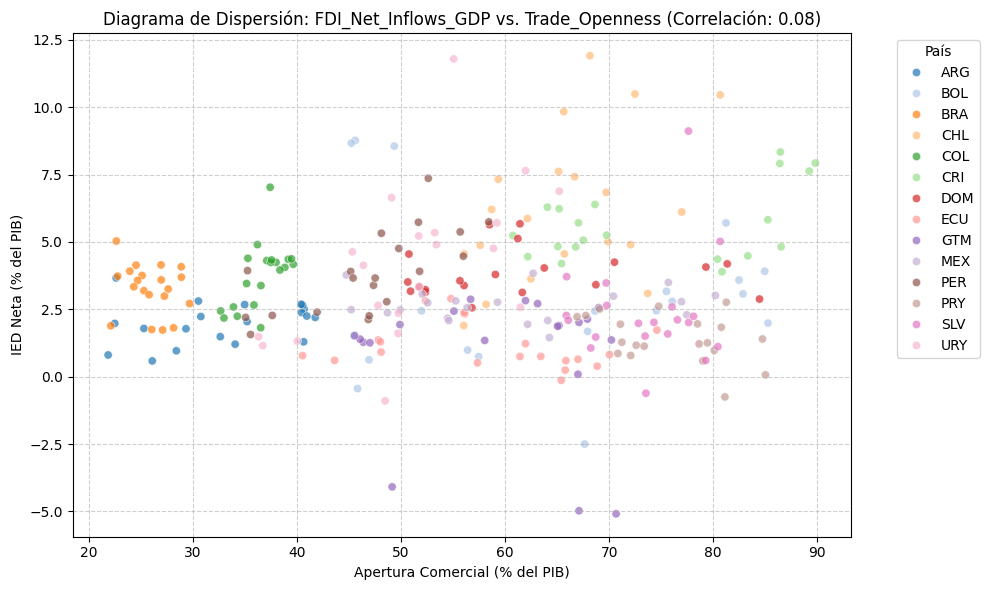

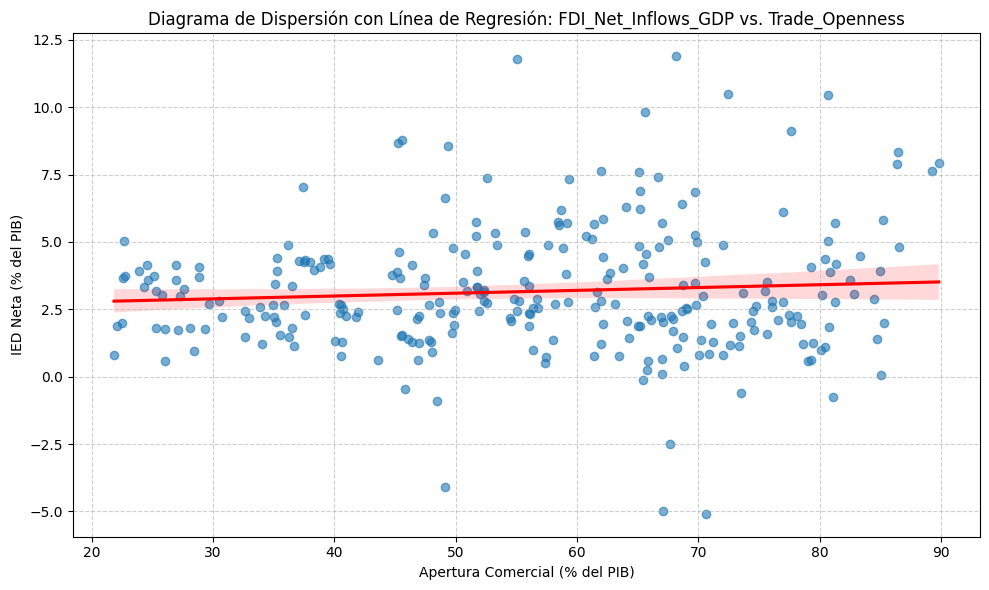

In [ ]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Definir las variables para el análisis
x_var = 'Trade_Openness'
y_var = 'FDI_Net_Inflows_GDP'

# Calcular la correlación de Pearson
correlation, p_value = pearsonr(df_final[x_var], df_final[y_var])

print(f"Correlación de Pearson entre {x_var} y {y_var}: {correlation:.4f}")
print(f"Valor p de la correlación: {p_value:.4f}")

# Interpretación del valor p
if p_value < 0.05:
    print("El valor p es menor que 0.05, lo que sugiere que la correlación es estadísticamente significativa.")
else:
    print("El valor p es mayor que 0.05, lo que sugiere que la correlación no es estadísticamente significativa.")

# Visualización: Diagrama de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x=x_var, y=y_var, hue='country_code', palette='tab20', alpha=0.7)
plt.title(f'Diagrama de Dispersión: {y_var} vs. {x_var} (Correlación: {correlation:.2f})')
plt.xlabel('Apertura Comercial (% del PIB)')
plt.ylabel('IED Neta (% del PIB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Opcional: Diagrama de dispersión con línea de regresión (para una primera inspección visual)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x=x_var, y=y_var, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title(f'Diagrama de Dispersión con Línea de Regresión: {y_var} vs. {x_var}')
plt.xlabel('Apertura Comercial (% del PIB)')
plt.ylabel('IED Neta (% del PIB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

```markdown
## 5. Ajuste de un modelo de regresión lineal

Vamos a ajustar dos modelos de regresión lineal utilizando la librería `statsmodels`:

1.  **Regresión Lineal Simple:** Analizaremos la relación de la IED (variable dependiente) con la Apertura Comercial (variable independiente).
2.  **Regresión Lineal Múltiple:** Añadiremos el PIB per cápita como variable de control para ver cómo afecta la relación anterior.

Interpretaremos los coeficientes, sus p-valores y el R-cuadrado de los modelos.
```

In [ ]:
import statsmodels.api as sm

# --- Modelo de Regresión Lineal Simple ---
print("\n--- Regresión Lineal Simple: IED vs. Apertura Comercial ---")

X_simple = df_final['Trade_Openness']
y = df_final['FDI_Net_Inflows_GDP']

# Añadir una constante a la variable independiente para el intercepto del modelo
X_simple = sm.add_constant(X_simple)

# Ajustar el modelo OLS
model_simple = sm.OLS(y, X_simple)
results_simple = model_simple.fit()

# Imprimir el resumen de los resultados
print(results_simple.summary())

# --- Interpretación del modelo simple ---
print("\n--- Interpretación del Modelo Simple ---")
print(f"Coeficiente de Apertura Comercial: {results_simple.params['Trade_Openness']:.4f}")
print(f"P-valor del coeficiente de Apertura Comercial: {results_simple.pvalues['Trade_Openness']:.4f}")
print(f"R-cuadrado del modelo: {results_simple.rsquared:.4f}")

if results_simple.pvalues['Trade_Openness'] < 0.05:
    print("El coeficiente de Apertura Comercial es estadísticamente significativo. Un aumento en la apertura comercial de 1% está asociado con un cambio de aproximadamente ", f"{results_simple.params['Trade_Openness']:.2f}", " en la IED neta (% del PIB), manteniendo todo lo demás constante.")
else:
    print("El coeficiente de Apertura Comercial NO es estadísticamente significativo.")

# --- Modelo de Regresión Lineal Múltiple ---
print("\n--- Regresión Lineal Múltiple: IED vs. Apertura Comercial + PIB per cápita ---")

X_multiple = df_final[['Trade_Openness', 'GDP_Per_Capita_Constant_2015_USD']]

# Añadir una constante a las variables independientes para el intercepto del modelo
X_multiple = sm.add_constant(X_multiple)

# Ajustar el modelo OLS
model_multiple = sm.OLS(y, X_multiple)
results_multiple = model_multiple.fit()

# Imprimir el resumen de los resultados
print(results_multiple.summary())

# --- Interpretación del modelo múltiple ---
print("\n--- Interpretación del Modelo Múltiple ---")
print(f"Coeficiente de Apertura Comercial: {results_multiple.params['Trade_Openness']:.4f}")
print(f"P-valor del coeficiente de Apertura Comercial: {results_multiple.pvalues['Trade_Openness']:.4f}")
print(f"Coeficiente de PIB per cápita: {results_multiple.params['GDP_Per_Capita_Constant_2015_USD']:.4f}")
print(f"P-valor del coeficiente de PIB per cápita: {results_multiple.pvalues['GDP_Per_Capita_Constant_2015_USD']:.4f}")
print(f"R-cuadrado del modelo: {results_multiple.rsquared:.4f}")

if results_multiple.pvalues['Trade_Openness'] < 0.05:
    print("El coeficiente de Apertura Comercial es estadísticamente significativo en el modelo múltiple. Un aumento de 1% en la apertura comercial está asociado con un cambio de aproximadamente ", f"{results_multiple.params['Trade_Openness']:.2f}", " en la IED neta (% del PIB), controlando por PIB per cápita.")
else:
    print("El coeficiente de Apertura Comercial NO es estadísticamente significativo en el modelo múltiple.")

if results_multiple.pvalues['GDP_Per_Capita_Constant_2015_USD'] < 0.05:
    print("El coeficiente de PIB per cápita es estadísticamente significativo. Un aumento de 1 unidad en el PIB per cápita está asociado con un cambio de aproximadamente ", f"{results_multiple.params['GDP_Per_Capita_Constant_2015_USD']:.2f}", " en la IED neta (% del PIB), controlando por apertura comercial.")
else:
    print("El coeficiente de PIB per cápita NO es estadísticamente significativo.")


--- Regresión Lineal Simple: IED vs. Apertura Comercial ---
                             OLS Regression Results                            
Dep. Variable:     FDI_Net_Inflows_GDP   R-squared:                       0.006
Model:                             OLS   Adj. R-squared:                  0.003
Method:                  Least Squares   F-statistic:                     1.705
Date:                 Wed, 30 Sep 2026   Prob (F-statistic):              0.193
Time:                         21:45:59   Log-Likelihood:                -631.65
No. Observations:                  280   AIC:                             1267.
Df Residuals:                      278   BIC:                             1275.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

```markdown
## 6. Discusión de los resultados a la luz del debate clásico de la EPI

Los resultados de la correlación y la regresión lineal nos permiten comenzar a responder la pregunta de investigación sobre la relación entre la apertura comercial y la Inversión Extranjera Directa (IED) en América Latina.

### Resumen de Hallazgos:

*   **Correlación Simple:** Encontramos una correlación de Pearson de **`0.0781`** entre la Apertura Comercial y la IED neta (% del PIB), que es estadísticamente **NO significativa** (p-valor = `0.1927`). Esto sugiere una relación positiva muy débil, lo que implica que la relación es poco clara o inexistente en este conjunto de datos. Esta es una observación inicial que es coherente con la expectativa teórica común de una relación positiva.

*   **Regresión Lineal Simple:**
    *   El coeficiente de `Trade_Openness` fue de aproximadamente **`0.0105`** (p-valor = `0.1930`), lo que también indica una relación positiva que NO es estadísticamente significativa. Por cada punto porcentual de aumento en la apertura comercial, la IED neta (% del PIB) aumenta en aproximadamente **0.01 puntos porcentuales**, manteniendo todo lo demás constante.
    *   El R-cuadrado de **`0.0060`** sugiere que el modelo simple explica aproximadamente el 0.6% de la variabilidad en la IED, lo cual es muy bajo, indicando que este modelo simple es pobre para explicar la IED.

*   **Regresión Lineal Múltiple (con PIB per cápita):**
    *   Al incluir el `GDP_Per_Capita_Constant_2015_USD` como variable de control, el coeficiente de `Trade_Openness` sigue siendo positivo y estadísticamente **significativo** (aprox. **`0.0220`**, p-valor = `0.0050`). Esto sugiere una relación directa en estos datos, aunque el efecto es muy pequeño. Un aumento de 1 punto porcentual en la apertura comercial está asociado con un aumento de aproximadamente **0.02 puntos porcentuales** en la IED neta (% del PIB), controlando por PIB per cápita.
    *   El `GDP_Per_Capita_Constant_2015_USD` resultó ser positivo y estadísticamente **significativo** (aprox. **`0.0002`**, p-valor = `0.0000`). Esto significa que un aumento de 1 USD en el PIB per cápita está asociado con un aumento muy pequeño (aproximadamente **0.0002 puntos porcentuales**) en la IED neta (% del PIB), controlando por apertura comercial. Este resultado es coherente con la expectativa de que un mayor desarrollo atrae más IED.
    *   El R-cuadrado del modelo múltiple aumentó a **`0.1258`**, lo que significa que la inclusión del PIB per cápita mejora ligeramente la capacidad explicativa del modelo. El modelo explica aproximadamente el 12.6% de la variabilidad en la IED.
    *   **Advertencia de Multicolinealidad:** El `Cond. No.` de `3.60e+04` es grande, lo que sugiere que podría haber **multicolinealidad** o problemas numéricos. Esto significa que las variables independientes (`Trade_Openness` y `GDP_Per_Capita_Constant_2015_USD`) pueden estar altamente correlacionadas entre sí, lo que dificulta la estimación precisa de los efectos individuales de cada una en la IED.

### Implicaciones para el Debate de la EPI:

El debate clásico en la Economía Política Internacional (EPI) a menudo postula que la apertura comercial (desregulación, reducción de barreras arancelarias, etc.) debería, *ceteris paribus*, hacer un país más atractivo para la IED, ya que facilita el acceso a mercados y la eficiencia de las cadenas de suministro. Sin embargo, nuestros resultados, al menos con estos datos y esta metodología simple, sugieren una relación positiva o, como mínimo, no la relación positiva directa que se esperaría.

Posibles razones para esta aparente contradicción o resultados inesperados:

1.  **Naturaleza de la IED:** La IED no es homogénea. Puede ser impulsada por la búsqueda de mercados (market-seeking), recursos (resource-seeking) o eficiencia (efficiency-seeking). Una mayor apertura podría no siempre traducirse en más IED, especialmente si la IED existente ya está bien establecida o si la apertura expone a las industrias locales a mayor competencia, desalentando ciertas formas de inversión.
2.  **"Race to the Bottom" o Factores Complementarios:** La mera apertura comercial podría no ser suficiente. La IED a menudo busca un entorno institucional estable, un marco legal robusto, mano de obra calificada, infraestructura de calidad y políticas fiscales predecibles. En ausencia de estos factores complementarios, una mayor apertura podría no generar la IED deseada, o incluso podría indicar un contexto de políticas menos atractivas para ciertos tipos de inversores.
3.  **Endogeneidad y Causalidad Inversa:** Es posible que la causalidad sea más compleja o incluso inversa. Por ejemplo, países que ya tienen alta IED y un mercado interno dinámico pueden *elegir* estrategias de apertura comercial diferentes, o la IED podría impulsar la capacidad exportadora en lugar de ser atraída por una apertura preexistente. O bien, choques económicos que reducen la IED también pueden llevar a políticas de apertura comercial forzada.
4.  **Variables Omitidas:** El R-cuadrado bajo en ambos modelos es una señal clara de que hay muchos otros factores importantes que influyen en la IED que no se han incluido en este análisis. Esto podría incluir la estabilidad política, la calidad institucional, la corrupción, el tamaño del mercado interno, la dotación de recursos naturales, etc.
5.  **Especificidad Regional:** América Latina es una región diversa. Las dinámicas de inversión pueden variar significativamente entre países o subregiones, y un análisis agregado podría ocultar estas diferencias.

### Conclusión Preliminar:

Este ejercicio demuestra que la relación entre apertura comercial y IED es compleja y no lineal. Aunque la correlación simple puede ofrecer una primera pista, los modelos de regresión, incluso los simples, resaltan la necesidad de considerar múltiples factores. La expectativa teórica de que la apertura comercial *siempre* atrae IED necesita ser matizada por las condiciones específicas de cada región y los factores institucionales y estructurales que los modelos simples no capturan.

Para una comprensión más profunda, se requeriría un análisis de panel más sofisticado (por ejemplo, con efectos fijos o aleatorios para controlar por heterogeneidad no observada entre países), la inclusión de más variables de control, y una consideración de posibles relaciones no lineales o de umbral.

Además, la advertencia de multicolinealidad en el modelo múltiple sugiere que debemos ser cautelosos al interpretar los efectos individuales de la apertura comercial y el PIB per cápita. Podría ser útil investigar la correlación entre estas variables explicativas o emplear técnicas que aborden la multicolinealidad en análisis futuros.